In [1]:
import kagglehub
from pathlib import Path
dataset_path = Path(kagglehub.dataset_download("emmanuelfwerr/thyroid-disease-data"))

d:\Documentos_TheReal\IA\PIA\Apuntes\Segunda Evaluación\ia25-master-main\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print(dataset_path) #Mediante esta línea obtenemos la ruta donde se ha guardado el dataset
import shutil
destino = "D:\\Documentos_TheReal\\IA\\PIA\\Apuntes\\Segunda Evaluación\\ia25-master-main\\sergio_ejercicios\\tiroides\\data" #Guardamos el dataset en la ruta que deseamos para poder trabajar con el
shutil.copytree(dataset_path, destino, dirs_exist_ok=True)

C:\Users\TheRealSerginho\.cache\kagglehub\datasets\emmanuelfwerr\thyroid-disease-data\versions\2


'D:\\Documentos_TheReal\\IA\\PIA\\Apuntes\\Segunda Evaluación\\ia25-master-main\\sergio_ejercicios\\tiroides\\data'

Una vez tenemos el dataset vamos a pasar a almacenarlo en una variable
-Debemos de tener claro que es un problema de tipo clasificación ya que el objectivo es deducir si tiene hipertiroidismo o hipo


In [3]:
import pandas as pd
data_tiroides= pd.read_csv("data/thyroidDF.csv")

In [4]:
data_tiroides.head()

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,target,patient_id
0,29,F,f,f,f,f,f,f,f,t,...,NaN,f,NaN,f,NaN,f,NaN,other,-,840801013
1,29,F,f,f,f,f,f,f,f,f,...,128.0,f,NaN,f,NaN,f,NaN,other,-,840801014
2,41,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,11.0,other,-,840801042
3,36,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,26.0,other,-,840803046
4,32,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,36.0,other,S,840803047


In [5]:
data_tiroides.info()

<class 'pandas.DataFrame'>
RangeIndex: 9172 entries, 0 to 9171
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  9172 non-null   int64  
 1   sex                  8865 non-null   str    
 2   on_thyroxine         9172 non-null   str    
 3   query_on_thyroxine   9172 non-null   str    
 4   on_antithyroid_meds  9172 non-null   str    
 5   sick                 9172 non-null   str    
 6   pregnant             9172 non-null   str    
 7   thyroid_surgery      9172 non-null   str    
 8   I131_treatment       9172 non-null   str    
 9   query_hypothyroid    9172 non-null   str    
 10  query_hyperthyroid   9172 non-null   str    
 11  lithium              9172 non-null   str    
 12  goitre               9172 non-null   str    
 13  tumor                9172 non-null   str    
 14  hypopituitary        9172 non-null   str    
 15  psych                9172 non-null   str    
 16 

In [6]:
data_tiroides.isnull().sum()

age                       0
sex                     307
on_thyroxine              0
query_on_thyroxine        0
on_antithyroid_meds       0
sick                      0
pregnant                  0
thyroid_surgery           0
I131_treatment            0
query_hypothyroid         0
query_hyperthyroid        0
lithium                   0
goitre                    0
tumor                     0
hypopituitary             0
psych                     0
TSH_measured              0
TSH                     842
T3_measured               0
T3                     2604
TT4_measured              0
TT4                     442
T4U_measured              0
T4U                     809
FTI_measured              0
FTI                     802
TBG_measured              0
TBG                    8823
referral_source           0
target                    0
patient_id                0
dtype: int64

In [7]:
import numpy as np

# Preserve original labels for traceability and idempotency
if "target_raw" not in data_tiroides.columns: #hacemos una copia de la columna target para preservar las etiquetas originales
    data_tiroides["target_raw"] = data_tiroides["target"]
data_tiroides["target"] = np.select(
    [
        data_tiroides["target_raw"].str.contains("[A-D]", na=False), 
        data_tiroides["target_raw"].str.contains("[E-H]", na=False)
    ],
    ["hyperthyroid", "hypothyroid"],
    default="negative"
)

print(f"Dataset shape: {data_tiroides.shape[0]} samples, {data_tiroides.shape[1]} features")
print("\nTarget distribution:")
display(pd.DataFrame({
    'Count': data_tiroides['target'].value_counts(),
    'Percentage (%)': (data_tiroides['target'].value_counts(normalize=True) * 100).round(1)
}))
     

Dataset shape: 9172 samples, 32 features

Target distribution:


,Count,Percentage (%)
target,,
negative,8264,90.1
hypothyroid,667,7.3
hyperthyroid,241,2.6


In [8]:
#Procedemos a eliminar las columnas que no aportan información relevante
data_tiroides.drop(columns=['patient_id', 'referral_source'], inplace=True)


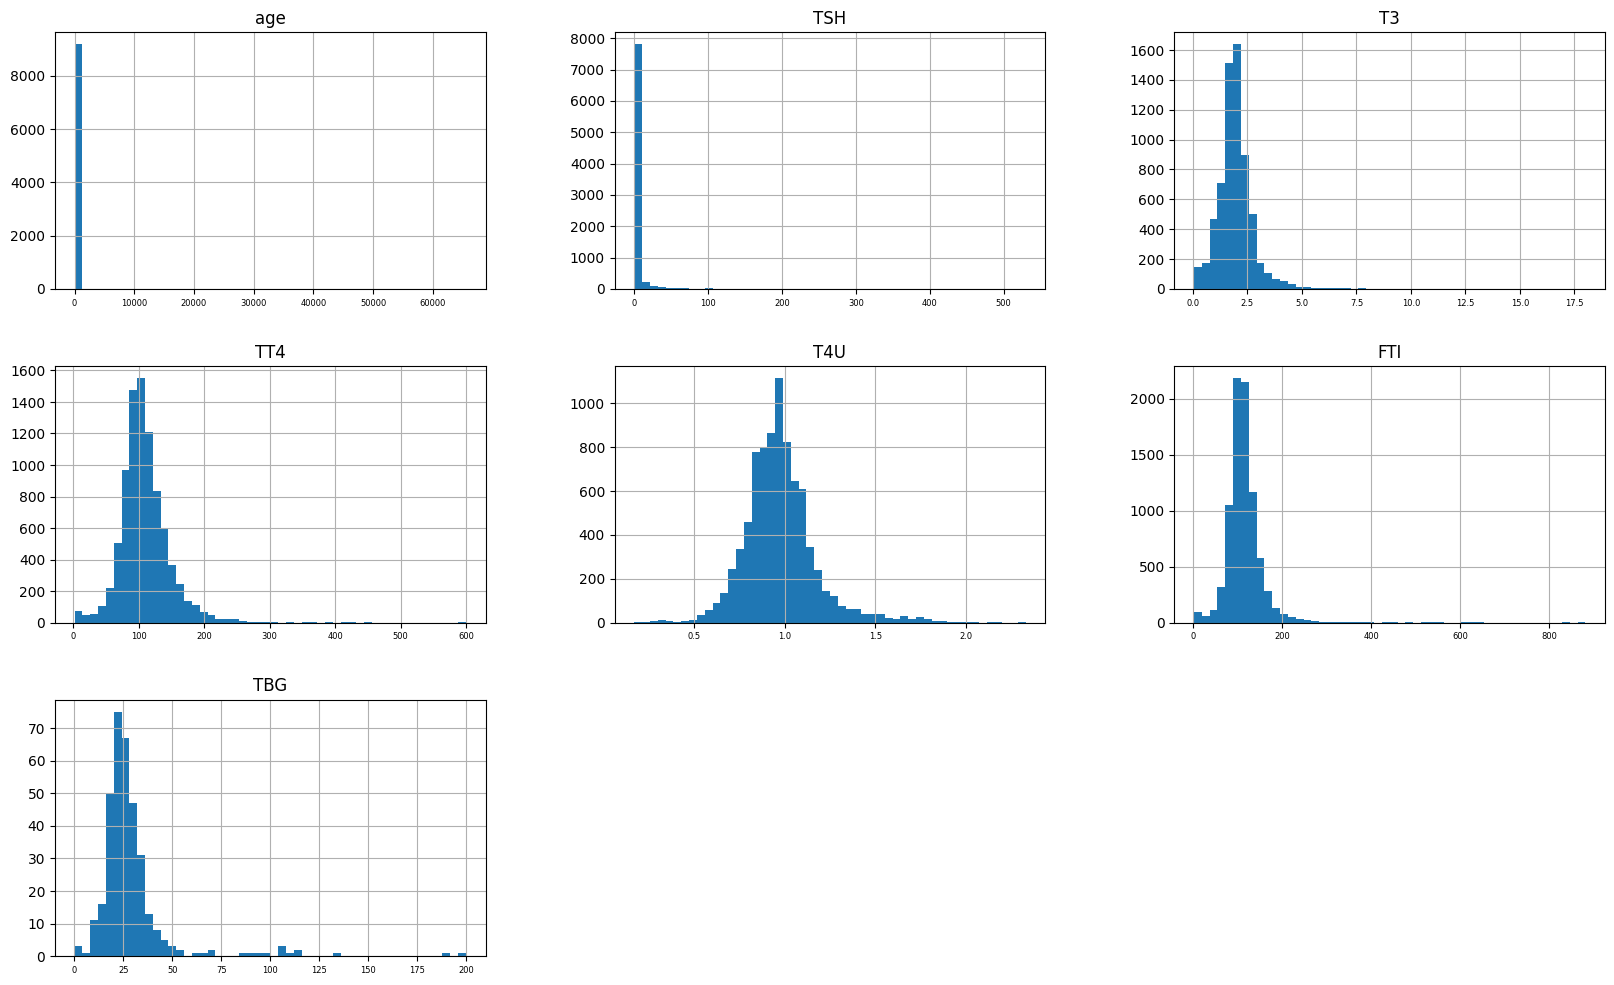

In [9]:
import matplotlib.pyplot as plt
_ = data_tiroides.hist(bins=50, figsize=(20, 12), xlabelsize=6) 

No es posible que cualquier persona tenga +150 años, por lo que vamos a tratar esta variable para que solamente coja valores hasta 100 años.

In [10]:
# Values of age over 100
data_tiroides[data_tiroides['age'] > 100]

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,target,target_raw
2976,455,F,f,f,f,f,f,f,f,f,...,t,118.0,t,1.13,t,104.0,f,NaN,negative,-
5710,65511,M,f,f,f,f,f,f,f,f,...,t,113.0,t,1.08,t,104.0,f,NaN,negative,-
6392,65512,M,f,f,f,f,f,f,f,f,...,t,112.0,t,0.84,t,133.0,f,NaN,negative,-
8105,65526,F,f,f,f,f,f,f,f,f,...,t,132.0,t,1.02,t,129.0,f,NaN,negative,-


<Axes: >

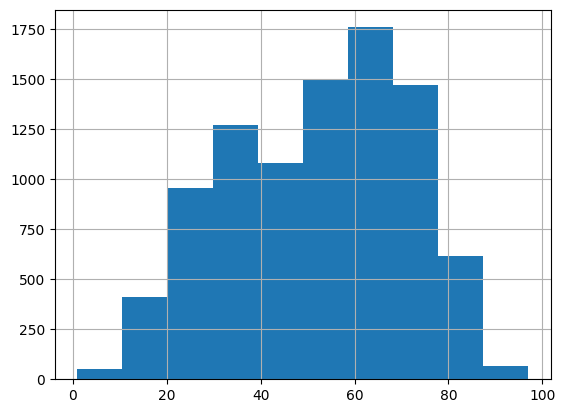

In [11]:
data_tiroides[data_tiroides['age'] < 100]['age'].hist()

Como solamente son 4 los valores que están por encima de 100 años estos pueden representar problema, si nos fijamos la edad es un dato inverosímil y esta generando outliers, por lo que lo que haremos será tratar estas columnas como valores nulos.

In [12]:
data_tiroides.loc[data_tiroides['age'] > 100, 'age'] = np.nan 
data_tiroides[data_tiroides['age'] > 100]

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,target,target_raw


Max Age is now: 97.0
TSH skewness before: 12.92
TSH skewness after log: 1.94


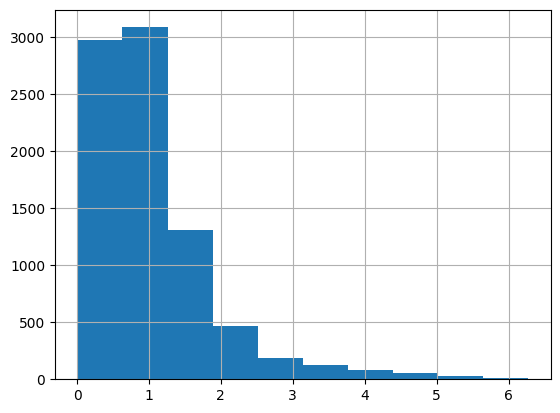

In [13]:
# We apply a log transformation. 
# We add +1 because log(0) is undefined, and TSH can be 0.
# Formula: TSH_log = log(TSH + 1)
data_tiroides['TSH_log'] = np.log1p(data_tiroides['TSH'])
print(f"Max Age is now: {data_tiroides['age'].max()}")
print(f"TSH skewness before: {data_tiroides['TSH'].skew():.2f}")
print(f"TSH skewness after log: {data_tiroides['TSH_log'].skew():.2f}")

_ = data_tiroides['TSH_log'].hist()

En este caso lo pasamos a logaritmo, "skewness" es básicamente la asimentría de la parábola, en el caso de que sea positiva significa que se alarga hacia la derecha del medio, en el caso contrario se alarga hacia la izquierda.

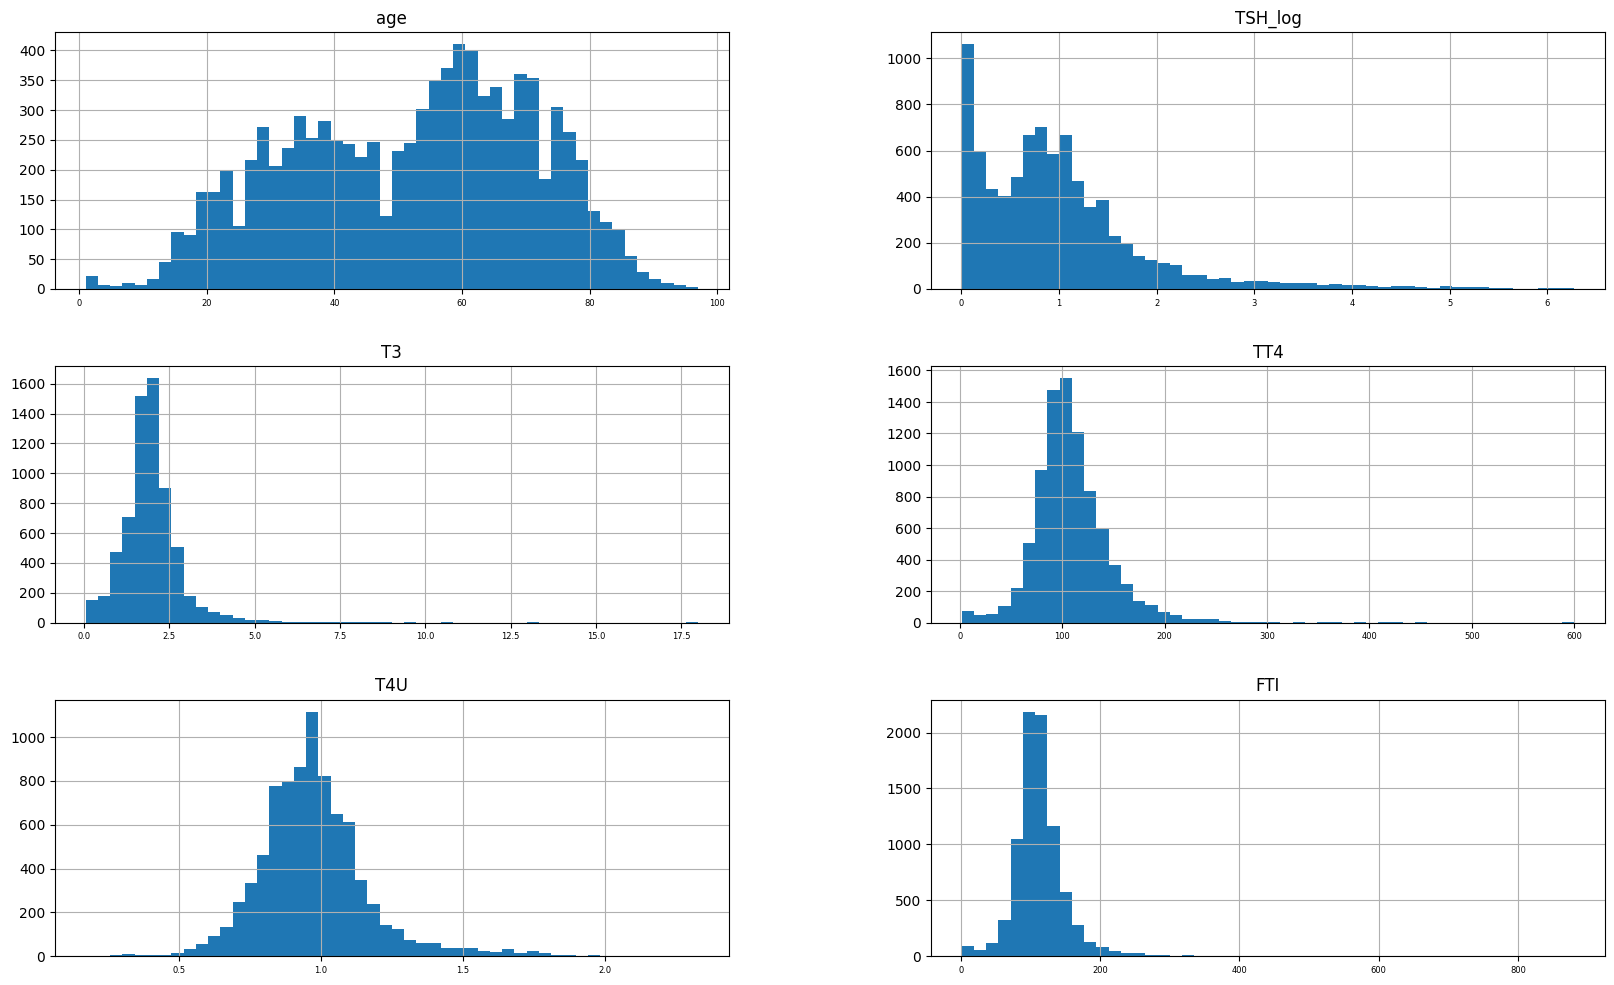

In [14]:
cleaned_cols = ['age', 'TSH_log', 'T3', 'TT4', 'T4U', 'FTI']
_ = data_tiroides[cleaned_cols].hist(bins=50, figsize=(20, 12), xlabelsize=6) 

In [15]:
data_tiroides.isnull().sum()

age                       4
sex                     307
on_thyroxine              0
query_on_thyroxine        0
on_antithyroid_meds       0
sick                      0
pregnant                  0
thyroid_surgery           0
I131_treatment            0
query_hypothyroid         0
query_hyperthyroid        0
lithium                   0
goitre                    0
tumor                     0
hypopituitary             0
psych                     0
TSH_measured              0
TSH                     842
T3_measured               0
T3                     2604
TT4_measured              0
TT4                     442
T4U_measured              0
T4U                     809
FTI_measured              0
FTI                     802
TBG_measured              0
TBG                    8823
target                    0
target_raw                0
TSH_log                 842
dtype: int64

In [16]:
# Verify relationship between _measured flags and NaN values
measured_cols = [col for col in data_tiroides.columns if col.endswith('_measured')]

for col in measured_cols:
    base_col = col.replace('_measured', '')
    if base_col in data_tiroides.columns:
        measured_true = (data_tiroides[col] == 't').sum()
        has_value = data_tiroides[base_col].notna().sum()
        print(f"{base_col}: measured='t' count = {measured_true}, non-null count = {has_value}")

TSH: measured='t' count = 8330, non-null count = 8330
T3: measured='t' count = 6568, non-null count = 6568
TT4: measured='t' count = 8730, non-null count = 8730
T4U: measured='t' count = 8363, non-null count = 8363
FTI: measured='t' count = 8370, non-null count = 8370
TBG: measured='t' count = 349, non-null count = 349


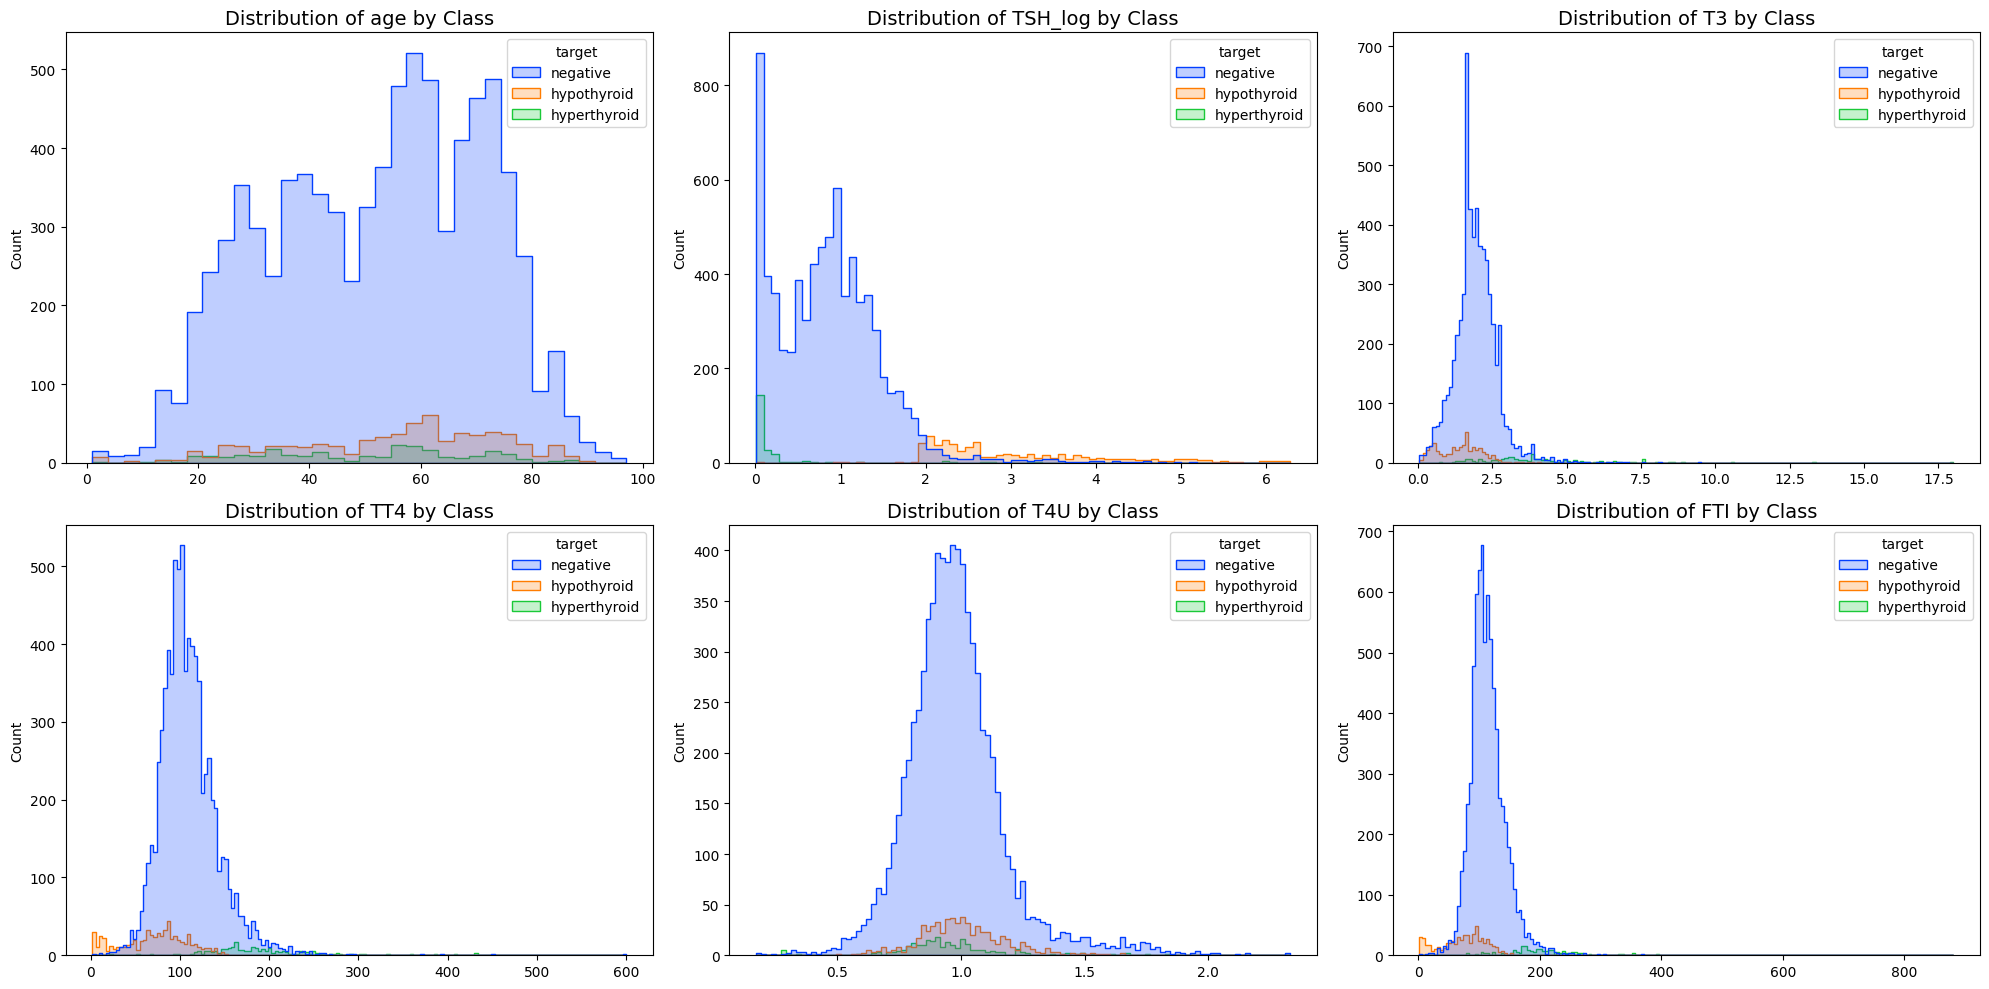

In [17]:
# pip install visualization
import sys
sys.path.insert(0, r'd:/Documentos_TheReal/IA/PIA/Apuntes/Segunda Evaluación/ia25-master-main/thyroid-master/src')
from visualization import plot_histograms_by_class
plot_histograms_by_class(data_tiroides, target_col='target', columns=cleaned_cols)

In [18]:
data_tiroides["target_num"] = data_tiroides["target"].map({
    "negative": 0,
    "hypothyroid": 1,
    "hyperthyroid": 2
})
data_tiroides["negativo"]= (data_tiroides["target"] == "negative").astype(int)
data_tiroides["hipotiroidismo"]= (data_tiroides["target"] == "hypothyroid").astype(int)
data_tiroides["hipertiroidismo"]= (data_tiroides["target"] == "hyperthyroid").astype(int)

In [19]:
#Primero calculamos las variables importantes para los casos de hipertiroidismo
correlaciones = data_tiroides.corr(numeric_only=True)

correlaciones["hipertiroidismo"].sort_values(ascending=False)

hipertiroidismo    1.000000
target_num         0.764829
T3                 0.408748
FTI                0.408594
TT4                0.352699
age               -0.019579
TBG               -0.025966
T4U               -0.026332
TSH               -0.030026
hipotiroidismo    -0.046003
TSH_log           -0.144459
negativo          -0.495577
Name: hipertiroidismo, dtype: float64

In [20]:
correlaciones = data_tiroides.corr(numeric_only=True)

correlaciones["hipotiroidismo"].sort_values(ascending=False)

hipotiroidismo     1.000000
TSH_log            0.673378
target_num         0.608368
TSH                0.445470
age                0.044340
T4U                0.037281
TBG               -0.027892
hipertiroidismo   -0.046003
T3                -0.184515
FTI               -0.281701
TT4               -0.286420
negativo          -0.844847
Name: hipotiroidismo, dtype: float64

In [21]:
correlaciones = data_tiroides.corr(numeric_only=True)

correlaciones["negativo"].sort_values(ascending=False)

negativo           1.000000
TT4                0.058651
TBG                0.038165
FTI                0.021848
T4U               -0.017955
age               -0.028067
T3                -0.070969
TSH               -0.379192
hipertiroidismo   -0.495577
TSH_log           -0.522841
hipotiroidismo    -0.844847
target_num        -0.938590
Name: negativo, dtype: float64

Teniendo estos datos nos vamos a quedar con las variables más importantes que son TT4,T3, age, TSH y TBG

In [22]:

import numpy as np
from sklearn.metrics import accuracy_score

# Imagine a test set of 1000 patients
# 900 negative (0), 50 hyperthyroid (1), 50 hypothyroid (2)
y_true = np.array([0]*900 + [1]*50 + [2]*50)

# A naive model that predicts EVERYONE is healthy ("negative")
y_pred_naive = np.zeros(1000)

accuracy = accuracy_score(y_true, y_pred_naive)
print(f"Naive Model Accuracy: {accuracy * 100:.2f}%")

from sklearn.metrics import recall_score

# The "Trivial Panic Model" - predicts everyone is sick!
# Let's say it flips a coin to predict either hyperthyroid (1) or hypothyroid (2) for EVERY patient
np.random.seed(42)
y_pred_panic = np.random.choice([1, 2], size=1000)

# Calculate Mean Thyroid Recall for this conceptually broken model
hyper_recall = recall_score(y_true, y_pred_panic, labels=[1], average=None)[0]
hypo_recall = recall_score(y_true, y_pred_panic, labels=[2], average=None)[0]

mean_recall = (hyper_recall + hypo_recall) / 2
print(f"Hyperthyroid Recall: {hyper_recall * 100:.2f}%")
print(f"Hypothyroid Recall: {hypo_recall * 100:.2f}%")
print(f"Thyroid Mean Recall Score: {mean_recall * 100:.2f}%")


from sklearn.metrics import fbeta_score

# Comparing our models with the robust Macro F2 score targeting ONLY the disease classes (1 and 2)
def print_f2(model_name, y_predictions):
    f2 = fbeta_score(y_true, y_predictions, beta=2, labels=[1, 2], average='macro', zero_division=0)
    print(f"{model_name} Disease F2 Score: {f2:.4f}")

print_f2("Naive Model", y_pred_naive)
print_f2("Panic Model", y_pred_panic)

# A good model that catches 90% of sicknesses with 50% precision
y_pred_good = y_true.copy()
# Add some false positives (50 healthy people predicted as sick)
y_pred_good[0:25] = 1
y_pred_good[25:50] = 2
# It misses a few (5 hyper and 5 hypo predicted as healthy)
y_pred_good[-55:-50] = 0
y_pred_good[-5:-1] = 0

print_f2("Clinically Useful Model", y_pred_good)

from sklearn.metrics import make_scorer

def thyroid_disease_f2_score(y_true, y_pred):
    """
    Macro F2-score targeting strictly the two thyroid disease classes.
    Handles both string labels and integer-encoded labels (alphabetical LabelEncoder ordering:
    hyperthyroid=0, hypothyroid=1, negative=2).
    """
    y_true = np.asarray(y_true)

    if np.issubdtype(y_true.dtype, np.integer) or (len(y_true) > 0 and isinstance(y_true[0], (int, np.integer))):
        h_label, l_label = 0, 1
    else:
        h_label, l_label = 'hyperthyroid', 'hypothyroid'

    return float(fbeta_score(y_true, y_pred, beta=2, labels=[h_label, l_label], average='macro', zero_division=0))

# This scorer is what we import as `thyroid_scorer` from src/metrics.py
thyroid_scorer = make_scorer(thyroid_disease_f2_score)

print("Scorer successfully created:", type(thyroid_scorer))



Naive Model Accuracy: 90.00%
Hyperthyroid Recall: 54.00%
Hypothyroid Recall: 60.00%
Thyroid Mean Recall Score: 57.00%
Naive Model Disease F2 Score: 0.0000
Panic Model Disease F2 Score: 0.2035
Clinically Useful Model Disease F2 Score: 0.8410
Scorer successfully created: <class 'sklearn.metrics._scorer._Scorer'>


Vamos a proceder a preparar y dividir el dataset


In [23]:
# Selecciona las columnas correctamente usando una lista de nombres de columnas
X = data_tiroides[["TSH", "T3", "TT4", "age"]]
y = data_tiroides["target"]

In [24]:
print(X.dtypes)
print (X.select_dtypes(include='object').columns)
print (X.select_dtypes(include='number').nunique())

TSH    float64
T3     float64
TT4    float64
age    float64
dtype: object
Index([], dtype='str')
TSH    369
T3      85
TT4    287
age     96
dtype: int64


In [25]:
# 1. Limpiar primero el dataframe completo
data_modelo = data_tiroides.dropna(subset=["age"]).copy()

# 2. Separar X e y desde el mismo dataframe limpio
X = data_modelo[["TSH", "T3", "TT4", "age"]].copy()
y = data_modelo["target"].copy()

# 3. Pasar a numérico
X = X.apply(pd.to_numeric, errors="coerce")

# 4. Crear indicador de missing
X["T3_missing"] = X["T3"].isnull().astype(int)

In [26]:
X = X.apply(pd.to_numeric, errors="coerce")
X.isnull().sum()
print (X.dtypes)
print(X.isnull().sum())

TSH           float64
T3            float64
TT4           float64
age           float64
T3_missing      int64
dtype: object
TSH            842
T3            2603
TT4            442
age              0
T3_missing       0
dtype: int64


In [27]:
#Vamos a tratar y ya que puede tener 3 valores
#Para esto usamos label_encoder
y = y.loc[X.index]
print(y.shape)
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)#convertimos las etiquetas a números, esto es necesario para que el modelo pueda trabajar con ellas
print(label_encoder.classes_)

print(X.shape)
print(y.shape)
print(y_encoded.shape)

(9168,)
['hyperthyroid' 'hypothyroid' 'negative']
(9168, 5)
(9168,)
(9168,)


In [28]:
print(X.head())
print(X.dtypes)

   TSH   T3    TT4   age  T3_missing
0  0.3  NaN    NaN  29.0           1
1  1.6  1.9  128.0  29.0           0
2  NaN  NaN    NaN  41.0           1
3  NaN  NaN    NaN  36.0           1
4  NaN  NaN    NaN  32.0           1
TSH           float64
T3            float64
TT4           float64
age           float64
T3_missing      int64
dtype: object


In [29]:
#Ahora ya podemos dividir el dataset, lo dividiremos en 3, train, validation y test
from sklearn.model_selection import train_test_split
X_train,val_X,y_train, val_y= train_test_split (X,y_encoded,test_size= 0.3, random_state=42, stratify=y_encoded)#Mediante stratify hacemos que se mantenga la proporción de clases en cada uno de los datasets
print ("El tamaño para el dataset de entrenamiento es: ", len(X_train))

X_val,X_test,y_val,y_test= train_test_split(val_X,val_y, test_size= 0.5, random_state=42,stratify=val_y)
print ("El tamaño para el dataset de validación es:", len(X_val))
print ("El tamaño para el dataset de test es:", len(X_test))


El tamaño para el dataset de entrenamiento es:  6417
El tamaño para el dataset de validación es: 1375
El tamaño para el dataset de test es: 1376


In [30]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_val = pd.DataFrame(
    imputer.transform(X_val),
    columns=X_val.columns,
    index=X_val.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [31]:
#Ahora procedemos a hacer el escalado
#Lo haremos mediante StandardScaler y solamente en train
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
scaler.fit(X_train)
X_train_scaled=scaler.transform(X_train)
X_val_scaled=scaler.transform(X_val)
X_test_scaled=scaler.transform(X_test)


In [32]:
X_train_scaled.mean()
X_train_scaled.std()

np.float64(1.0)

In [33]:
#Ahora vamos a proceder a entrenar un modelo de regresión logística
#Empezamos a entrenar el modelo con los datos de train
from sklearn.linear_model import LogisticRegression
modelo_regresion= LogisticRegression(max_iter=1000, random_state=42)
modelo_regresion.fit(X_train_scaled,y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [34]:
#Ahora procedemos a predecir en validación
y_val_pred= modelo_regresion.predict(X_val_scaled)

In [35]:
#Por último toca evaluar el modelo, para esto vamos a usar la métrica que hemos creado anteriormente, el thyroid_disease_f2_score
#Escogemos esta métrica porque en nuestro caso queremos que el recall sea alto, esto quiere decir que preferimos detectar una persona sana como enferma a que se nos escape el caso de un enfermo que detectemos como positivo.
#Esto quiere decir que preferimos tener falsos positivos (sanos como enfermos) a falsos negativos (enfermos como sanos)
from sklearn.metrics import fbeta_score
f2 = fbeta_score(y_val, y_val_pred, beta=2, average='macro')#Con average="macro" tratamos todas las variables por igual
#En el caso de ponerlo a weighted tendría en cuenta el tamaño de cada clase

print("F2-score:", f2)


F2-score: 0.5861959363312153


In [36]:
f2_per_class = fbeta_score(y_val, y_val_pred, beta=2, average=None)
print(f2_per_class)

[0.3125     0.47149123 0.97459658]


In [37]:
import numpy as np

print(np.unique(y_val_pred, return_counts=True))

(array([0, 1, 2]), array([  16,   56, 1303]))


In [38]:
print(label_encoder.classes_)

['hyperthyroid' 'hypothyroid' 'negative']


In [39]:
print(np.unique(y_val, return_counts=True))

(array([0, 1, 2]), array([  36,  100, 1239]))


In [40]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_val, y_val_pred, target_names=label_encoder.classes_))
print(confusion_matrix(y_val, y_val_pred))

              precision    recall  f1-score   support

hyperthyroid       0.62      0.28      0.38        36
 hypothyroid       0.77      0.43      0.55       100
    negative       0.94      0.98      0.96      1239

    accuracy                           0.93      1375
   macro avg       0.78      0.56      0.63      1375
weighted avg       0.92      0.93      0.92      1375

[[  10    0   26]
 [   0   43   57]
 [   6   13 1220]]


log_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_model.fit(X_train_scaled, y_train)

f2_per_class = fbeta_score(y_val, y_val_pred, beta=2, average=None)
print(f2_per_class)

print(classification_report(y_val, y_val_pred, target_names=label_encoder.classes_))
print(confusion_matrix(y_val, y_val_pred))

log_model2= LogisticRegression(
    max_iter=1000,
    class_weight={0: 1, 1: 5, 2: 10},  # Ajusta estos valores según las clases
    random_state=42
)
log_model2.fit(X_train_scaled, y_train)

f2_per_class = fbeta_score(y_val, y_val_pred, beta=2, average=None)
print(f2_per_class)

print(classification_report(y_val, y_val_pred, target_names=label_encoder.classes_))
print(confusion_matrix(y_val, y_val_pred))

In [41]:
#pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

# Aplica SMOTE solo al conjunto de entrenamiento
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# Ahora entrena el modelo con el conjunto balanceado
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_res, y_train_res)
from sklearn.metrics import fbeta_score, classification_report, confusion_matrix

# Predicciones con el modelo
y_val_pred = log_model.predict(X_val_scaled)

# F2 score
f2_per_class = fbeta_score(y_val, y_val_pred, beta=2, average=None)
print(f2_per_class)

# Classification report
print(classification_report(y_val, y_val_pred, target_names=label_encoder.classes_))

# Confusion matrix
print(confusion_matrix(y_val, y_val_pred))

[0.48192771 0.87406015 0.86923973]
              precision    recall  f1-score   support

hyperthyroid       0.17      0.89      0.29        36
 hypothyroid       0.70      0.93      0.80       100
    negative       0.99      0.84      0.91      1239

    accuracy                           0.85      1375
   macro avg       0.62      0.89      0.67      1375
weighted avg       0.95      0.85      0.89      1375

[[  32    0    4]
 [   1   93    6]
 [ 155   39 1045]]
